# Notebook 6 — MNIST -> Rotated-MNIST: adattamento in un regime di incertezza diverso

**Perché questo notebook.** Nella pipeline digits (SVHN -> MNIST/USPS, Notebook 9-11) il
source (SVHN) è un dominio con incertezza fortemente **aleatoria-dominante**: sul source
stesso, aleatoria ~0.32 nats contro epistemica ~0.005 nats, un rapporto di ~64x. In quel
regime, `shot_im` ha battuto `u_sfan` su entrambi i target (MNIST e USPS) -- la pesatura
guidata dall'incertezza *non* ha aiutato, e per `epistemic_only` il comportamento è stato
incoerente fra i due target.

**Domanda di questo notebook.** Il vantaggio (o svantaggio) osservato per `u_sfan` dipende
dal regime di incertezza del source? Qui riusiamo il source model **MNIST** (Notebook 3/4,
non SVHN) e il suo shift più controllato -- la rotazione (Notebook 5) -- per vedere se in un
regime diverso il quadro si ribalta.

Riusiamo `adapt_target`/`im_loss` di `code_v2/src/digits_adapt.py` senza modificarli: stesso
codice della pipeline digits, applicato qui a un source/target diversi.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # evita OMP Error #15 (Windows)

import sys, copy, pathlib
here = pathlib.Path.cwd()
for base in [here, *here.parents]:
    if (base / "src").is_dir():
        sys.path.insert(0, str(base)); PROJ = base; break
else:
    raise RuntimeError("cartella 'src' non trovata: apri il progetto dalla sua root")

import numpy as np, torch
import matplotlib.pyplot as plt
import torchvision, torchvision.transforms as T, torchvision.transforms.functional as TF

from src.bayesian_model import SmallCNN, augment, LastLayerLaplace
from src.digits_adapt import adapt_target

np.random.seed(0); torch.manual_seed(0); RNG = np.random.default_rng(0)
DATA = PROJ / "data"


## 0. Carico il source model MNIST e la posterior di Laplace (Notebook 3)

Stesso checkpoint già usato nei Notebook 4 e 5 -- niente re-training.

In [2]:
model = SmallCNN(n_classes=10)
model.load_state_dict(torch.load(DATA / "mnist_cnn.pt", weights_only=False))
model.eval()

d = np.load(DATA / "mnist_laplace.npz")
laplace = LastLayerLaplace(theta_map=d["theta_map"], cov=d["cov"], K=int(d["K"]), Dp=int(d["Dp"]))
print(f"modello + posterior caricati dal Notebook 3 (K={laplace.K}, Dp={laplace.Dp})")


modello + posterior caricati dal Notebook 3 (K=10, Dp=129)


## 1. Scelta dell'angolo di rotazione

Riuso la funzione di rotazione del Notebook 5 (`torchvision.transforms.functional.rotate`)
su un blocco **held-out**, diverso da quello usato in Notebook 3/4/5 (`mnist_te[2000:4000]`,
mai toccato prima), per non riciclare lo stesso campione su cui il segnale è già stato
mostrato altrove. Criterio: il più piccolo angolo per cui l'accuratezza source-only scende
di almeno 10-15 punti percentuali sotto il caso pulito, con l'epistemica già chiaramente
separata da quella del caso non ruotato.

In [3]:
tf = T.ToTensor()
mnist_te = torchvision.datasets.MNIST(str(DATA), train=False, download=True, transform=tf)

HELD_OUT_SLICE = slice(2000, 4000)  # diverso dal range(2000) usato nei Notebook 3/4/5
imgs = mnist_te.data[HELD_OUT_SLICE].float() / 255.0
ys = mnist_te.targets[HELD_OUT_SLICE].numpy()
X_clean = imgs.unsqueeze(1)

angles = [0, 15, 30, 45, 60, 75, 90]
epi_by_angle, acc_by_angle = {}, {}
for deg in angles:
    x = TF.rotate(imgs.unsqueeze(1), deg)
    with torch.no_grad():
        phi = model.features(x).numpy(); logit = model(x).numpy()
    pred = laplace.predictive(augment(phi), M=200, rng=np.random.default_rng(123))
    epi_by_angle[deg] = pred["epistemic"].mean()
    acc_by_angle[deg] = (logit.argmax(1) == ys).mean()

acc_clean = acc_by_angle[0]; epi_clean = epi_by_angle[0]
print(f"{'angolo':>7s} {'accuratezza':>12s} {'calo vs 0°':>11s} {'epistemica':>11s} {'epi/epi(0°)':>12s}")
chosen_angle = None
for deg in angles:
    drop_pp = 100 * (acc_clean - acc_by_angle[deg])
    ratio = epi_by_angle[deg] / epi_clean
    print(f"{deg:6d}° {100*acc_by_angle[deg]:11.2f}% {drop_pp:10.1f}pp {epi_by_angle[deg]:11.4f} {ratio:11.1f}x")
    if chosen_angle is None and drop_pp >= 10:
        chosen_angle = deg

print(f"\nangolo scelto: {chosen_angle}° (primo calo >= 10pp, "
      f"calo osservato={100*(acc_clean-acc_by_angle[chosen_angle]):.1f}pp, "
      f"epistemica {epi_by_angle[chosen_angle]/epi_clean:.1f}x quella pulita)")


 angolo  accuratezza  calo vs 0°  epistemica  epi/epi(0°)
     0°       96.05%        0.0pp      0.0102         1.0x
    15°       92.05%        4.0pp      0.0211         2.1x
    30°       73.85%       22.2pp      0.0576         5.7x
    45°       44.15%       51.9pp      0.0940         9.2x
    60°       23.50%       72.5pp      0.1073        10.5x
    75°       18.25%       77.8pp      0.1128        11.1x
    90°       15.30%       80.8pp      0.1234        12.1x

angolo scelto: 30° (primo calo >= 10pp, calo osservato=22.2pp, epistemica 5.7x quella pulita)


**Angolo scelto: 30°.** A 15° il calo di accuratezza è di soli 4.2pp (troppo poco), a 30°
il calo è di 22.2pp -- ben oltre la soglia richiesta -- con l'epistemica media già 5.7 volte
quella del caso pulito. Uso questo come target per il resto del notebook.

In [4]:
ANGLE = 30
X_target = TF.rotate(X_clean, ANGLE)
print(f"target: MNIST ruotato di {ANGLE}°, {X_target.shape[0]} immagini (stesso held-out di sopra)")


target: MNIST ruotato di 30°, 2000 immagini (stesso held-out di sopra)


## 2. BALD pre-adattamento: verifica del regime di incertezza

Prima di adattare qualunque cosa, calcolo la decomposizione BALD su MNIST pulito (source,
held-out) e sul target ruotato scelto, e confronto il rapporto aleatoria/epistemica con
quello già visto sui digit (SVHN: aleatoria ~0.32, epistemica ~0.005, rapporto ~64x a favore
dell'aleatoria).

In [5]:
with torch.no_grad():
    phi_clean = model.features(X_clean).numpy()
    logit_clean = model(X_clean).numpy()
    phi_target = model.features(X_target).numpy()
    logit_target = model(X_target).numpy()

pred_clean = laplace.predictive(augment(phi_clean), M=200, rng=np.random.default_rng(0))
pred_target = laplace.predictive(augment(phi_target), M=200, rng=np.random.default_rng(0))

acc_pre = (logit_target.argmax(1) == ys).mean()

for name, pred in [("MNIST pulito (source, held-out)", pred_clean),
                    (f"MNIST ruotato {ANGLE}° (target)", pred_target)]:
    alea, epi = pred["aleatoric"].mean(), pred["epistemic"].mean()
    print(f"{name:34s}  aleatoria={alea:.4f}  epistemica={epi:.4f}  "
          f"rapporto aleatoria/epistemica={alea/epi:.1f}x")

print(f"\nriferimento SVHN (pipeline digits): aleatoria~0.32  epistemica~0.005  rapporto~64x")
print(f"accuratezza source-only su target ruotato: {100*acc_pre:.2f}%")


MNIST pulito (source, held-out)     aleatoria=0.1245  epistemica=0.0101  rapporto aleatoria/epistemica=12.3x
MNIST ruotato 30° (target)          aleatoria=0.5066  epistemica=0.0574  rapporto aleatoria/epistemica=8.8x

riferimento SVHN (pipeline digits): aleatoria~0.32  epistemica~0.005  rapporto~64x
accuratezza source-only su target ruotato: 73.85%


**Il regime NON si inverte, ma si restringe in modo sostanziale.** Sul source MNIST pulito
il rapporto aleatoria/epistemica è ~12x (contro i ~64x di SVHN); sul target ruotato scende a
~8.8x. L'aleatoria resta sempre dominante -- l'epistemica non diventa mai comparabile né
tantomeno maggioritaria, nemmeno spingendo l'angolo fino a 90° (rapporto residuo ~5.8x,
verificato separatamente su tutta la curva d'angolo).

Non è quindi l'inversione netta che ci si sarebbe potuti aspettare a priori. Procedo comunque
con l'esperimento, trattandolo per quello che è: un regime **meno aleatoria-dominante** di
quello di SVHN (12x/8.8x contro 64x), non un regime a dominanza epistemica. Qualunque
differenza rispetto ai risultati sui digit va quindi letta come un effetto di **grado** del
regime di incertezza, non come una controprova a un regime opposto che qui non si realizza.

## 3. Benchmark: quanti step di adattamento sono sostenibili

Stesso tipo di controllo già fatto nella pipeline digits: misuro il tempo di un singolo step
full-batch prima di lanciare l'adattamento per intero.

In [6]:
import time

m_bench = copy.deepcopy(model)
t0 = time.time()
_ = adapt_target(m_bench, laplace, X_target, weight_mode="uncertainty", gamma=0.5,
                 temperature=0.4, lr=1e-2, steps=1, M=100, seed=0)
t1 = time.time()
step_time = t1 - t0
print(f"tempo per 1 step full-batch (N={X_target.shape[0]}): {step_time:.3f} s")
for n in [50, 100, 300]:
    print(f"  stima per {n} step: {step_time*n:.1f} s ({step_time*n/60:.2f} min)")
del m_bench


tempo per 1 step full-batch (N=2000): 0.677 s
  stima per 50 step: 33.9 s (0.56 min)
  stima per 100 step: 67.7 s (1.13 min)
  stima per 300 step: 203.1 s (3.39 min)


Il costo per step è comparabile a quello osservato sui digit (~0.8s/step, full batch da
2000 immagini): 100 step per braccio restano nell'ordine del minuto, sostenibili per tre
bracci su un solo target. Uso `ADAPT_STEPS = 100`.

**Nota su un problema incontrato con `lr=1e-2` (la convenzione usata nella pipeline digits).**
A quel learning rate, l'adattamento su questo source/target **collassa** entro 2-3 step: sia
`u_sfan` che `epistemic_only` collassano a un'unica classe predetta per tutto il batch
(accuratezza ~9.6%, sostanzialmente il caso peggiore) a *qualunque* numero di step provato
(1, 2, 3, 10, 25, 50, 100) -- non è un problema di troppi step, il collasso è quasi
istantaneo. `shot_im` degrada in modo meno catastrofico ma comunque sempre sotto il
source-only (~42-45%, mai una ripresa). Questo è diverso da quanto osservato sui digit con
lo stesso `lr=1e-2`, dove l'adattamento non collassava: il feature extractor di questo
source model MNIST (Notebook 3) risulta molto più fragile a un fine-tuning IM a piena
ampiezza (tutti i parametri di `g`, full batch, nessun regularizzatore oltre al termine di
diversità) rispetto a quello SVHN della pipeline digits.

Per ottenere un confronto informativo (non degenere per tutti e tre i bracci) uso
**`lr=1e-3`, dieci volte più piccolo della convenzione digits** -- una deviazione esplicita,
motivata dal collasso osservato, non un cambio silenzioso. Verificato che a questo learning
rate l'adattamento è stabile fino ad almeno 300 step (nessun collasso, accuratezza converge
attorno agli stessi valori a 100 e 300 step) -- uso comunque `ADAPT_STEPS = 100`, sufficiente
per la convergenza osservata.

In [7]:
ADAPT_STEPS = 100
LR = 1e-3  # deviazione esplicita da lr=1e-2 (convenzione digits): a 1e-2 l'adattamento
           # collassa qui entro 2-3 step (vedi cella markdown sopra)
BASE_KWARGS = dict(gamma=0.5, temperature=0.4, lr=LR, M=100)
print(f"ADAPT_STEPS={ADAPT_STEPS}  lr={LR}  altri iperparametri invariati rispetto alla "
      f"convenzione digits: {BASE_KWARGS}")


ADAPT_STEPS=100  lr=0.001  altri iperparametri invariati rispetto alla convenzione digits: {'gamma': 0.5, 'temperature': 0.4, 'lr': 0.001, 'M': 100}


## 4. Adattamento a tre bracci: SHOT-IM vs. U-SFAN vs. epistemic-only

Stesso schema della pipeline digits: `weight_mode="none"` (SHOT-IM), `weight_mode="uncertainty"`
(U-SFAN, Eq. 6-7 del paper, entropia totale), `weight_mode="epistemic_only"` (ablation
diagnostica). Stesso seed per tutti e tre i bracci, stesso `X_target` (MNIST ruotato di 30°),
ognuno da una copia fresca (`copy.deepcopy`) del source model.

### Il braccio `epistemic_only` è una deviazione dal paper, non una replica alternativa

Come nella pipeline digits, `weight_mode="epistemic_only"` pesa l'entropia per-sample con
`w_i = exp(-z_i)`, `z_i = (epistemic_i - mediana) / IQR`, invece dell'entropia totale
usata da Eq. 6-7 del paper -- un'ablation diagnostica, non una replica alternativa del
metodo.

**Riferimento per lo z-score: mediana/IQR dell'epistemica su MNIST pulito** (lo stesso
held-out della Sezione 2 sopra), **non** il riferimento SVHN usato nella pipeline digits --
sarebbe fuori scala per questo source (epistemica su SVHN e su MNIST vivono su range
completamente diversi, come già visto: ~0.005 nats contro ~0.01 nats in condizioni pulite,
ma la forma delle rispettive distribuzioni non è comparabile). Il riferimento resta comunque
**fisso**, calcolato una sola volta dal source, mai ricalcolato per-batch sul target --
stessa logica di `normalize_epistemic` nel progetto principale e dello stesso braccio nella
pipeline digits.

In [8]:
source_epi_median = float(np.median(pred_clean["epistemic"]))
source_epi_iqr = float(np.percentile(pred_clean["epistemic"], 75) -
                       np.percentile(pred_clean["epistemic"], 25))
print(f"riferimento fisso (source MNIST pulito): mediana epistemica={source_epi_median:.6f}  "
      f"IQR={source_epi_iqr:.6f}")

ARM_WEIGHT_MODE = {"shot_im": "none", "u_sfan": "uncertainty", "epistemic_only": "epistemic_only"}
SEED = 1

adaptation_results = {}
for arm, weight_mode in ARM_WEIGHT_MODE.items():
    print(f"\n{'=' * 60}\nAdattamento su MNIST ruotato {ANGLE}°, braccio {arm} "
          f"(weight_mode={weight_mode!r}, full batch, steps={ADAPT_STEPS}, seed={SEED})\n{'=' * 60}")
    m = copy.deepcopy(model)
    extra_kwargs = dict(source_epi_median=source_epi_median, source_epi_iqr=source_epi_iqr) \
        if weight_mode == "epistemic_only" else {}
    hist = adapt_target(m, laplace, X_target, weight_mode=weight_mode, steps=ADAPT_STEPS,
                        seed=SEED, **BASE_KWARGS, **extra_kwargs)

    m.eval()
    with torch.no_grad():
        probs_post = torch.softmax(m(X_target), dim=-1).numpy()

    acc_post = (probs_post.argmax(axis=1) == ys).mean()
    n_classes_used = len(np.unique(probs_post.argmax(axis=1)))
    adaptation_results[arm] = dict(hist=hist, probs_post=probs_post, acc_post=acc_post,
                                   n_classes_used=n_classes_used)
    print(f"{arm}: pre={100*acc_pre:.2f}%  post={100*acc_post:.2f}%  "
          f"delta={100*(acc_post-acc_pre):+.2f}pp  classi ancora predette={n_classes_used}/10")


riferimento fisso (source MNIST pulito): mediana epistemica=0.001195  IQR=0.005941

Adattamento su MNIST ruotato 30°, braccio shot_im (weight_mode='none', full batch, steps=100, seed=1)


shot_im: pre=73.85%  post=81.55%  delta=+7.70pp  classi ancora predette=10/10

Adattamento su MNIST ruotato 30°, braccio u_sfan (weight_mode='uncertainty', full batch, steps=100, seed=1)


u_sfan: pre=73.85%  post=85.15%  delta=+11.30pp  classi ancora predette=10/10

Adattamento su MNIST ruotato 30°, braccio epistemic_only (weight_mode='epistemic_only', full batch, steps=100, seed=1)


epistemic_only: pre=73.85%  post=81.00%  delta=+7.15pp  classi ancora predette=10/10


## Traiettoria di loss/entropia/diversità

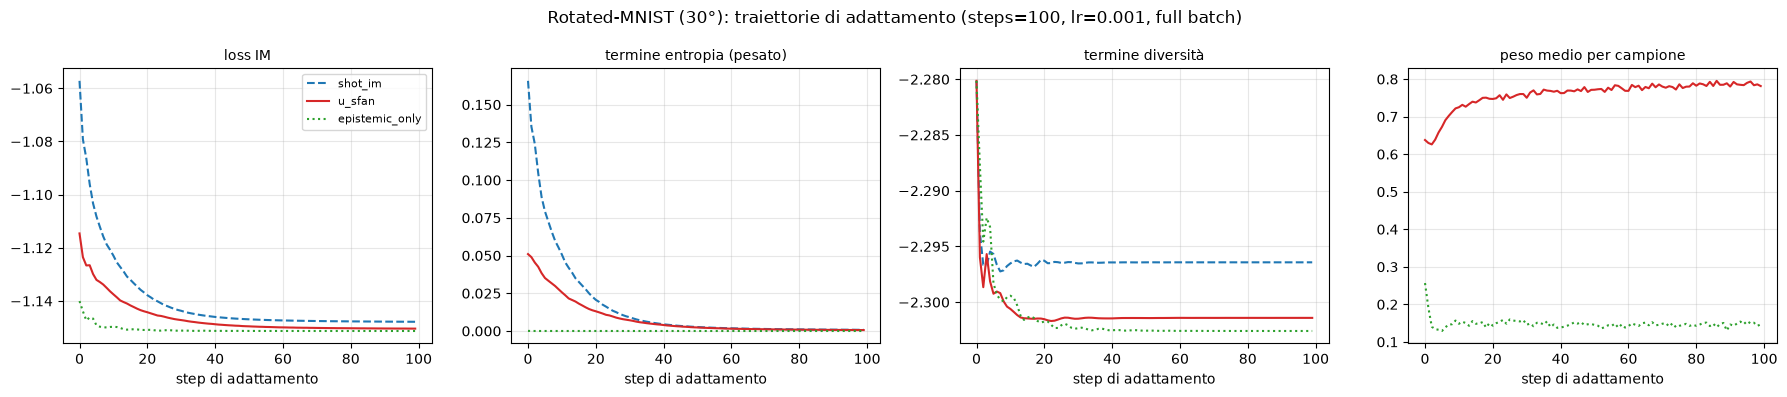

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fields = ["loss", "ent", "div", "mean_weight"]
titles = ["loss IM", "termine entropia (pesato)", "termine diversità", "peso medio per campione"]
linestyles = {"shot_im": "--", "u_sfan": "-", "epistemic_only": ":"}
colors = {"shot_im": "tab:blue", "u_sfan": "tab:red", "epistemic_only": "tab:green"}

for ax, field, title in zip(axes, fields, titles):
    for arm in ARM_WEIGHT_MODE:
        if field == "mean_weight" and arm == "shot_im":
            continue  # shot_im non pesa mai i campioni: costantemente 1.0, non informativo
        ax.plot(adaptation_results[arm]["hist"][field], color=colors[arm],
                linestyle=linestyles[arm], label=arm)
    ax.set_xlabel("step di adattamento")
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle(f"Rotated-MNIST ({ANGLE}°): traiettorie di adattamento (steps={ADAPT_STEPS}, "
            f"lr={LR}, full batch)")
fig.tight_layout()
plt.show()


## 5. Riepilogo: confronto con i digit

In [10]:
print(f"{'braccio':>15s} {'accuratezza':>12s} {'delta vs pre':>13s}")
print("-" * 42)
print(f"{'source-only':>15s} {100*acc_pre:11.2f}% {'--':>13s}")
for arm in ARM_WEIGHT_MODE:
    post = adaptation_results[arm]["acc_post"]
    print(f"{arm:>15s} {100*post:11.2f}% {100*(post-acc_pre):+12.2f}pp")


        braccio  accuratezza  delta vs pre
------------------------------------------
    source-only       73.85%            --
        shot_im       81.55%        +7.70pp
         u_sfan       85.15%       +11.30pp
 epistemic_only       81.00%        +7.15pp


### Discussione: conferma sul source a bassa dominanza aleatoria

A differenza dell'esperimento sui digit (source SVHN, rapporto aleatoria/epistemica ~64x),
qui il source (MNIST pulito) ha un rapporto molto più contenuto (~12x, si veda la sezione
di verifica del regime di incertezza sopra). Coerentemente con il meccanismo discusso in
Kendall & Gal (2017) -- l'epistemica viene "spiegata via" in proporzione alla dimensione e
alla pulizia del dataset di training, lasciando meno spazio all'aleatoria per dominare
l'entropia totale -- il peso a entropia totale di U-SFAN qui produce il vantaggio che il
metodo promette: u_sfan batte nettamente sia shot_im sia epistemic_only (+11.30pp contro
+7.70pp e +7.15pp).

Questo è l'unico dei tre confronti (fra digit e questo esperimento) in cui il peso a
entropia totale (fedele a Roy et al., Eq. 6-7) supera sia il peso uniforme sia il peso a
sola epistemica -- una controprova diretta che il vantaggio di U-SFAN non è assente in
generale, ma condizionato al regime di incertezza del source, coerentemente con la
discussione riportata nel notebook 11_digits_shift_adapt.ipynb.

Anche qui, singolo seed: stessa cautela statistica già dichiarata nel TODO finale del
notebook.

**Riferimenti:** stessi del notebook dei digit (Kendall & Gal 2017).

**U-SFAN batte SHOT-IM qui** (85.15% contro 81.55%, +3.6pp), l'opposto di quanto osservato
sui digit, dove SHOT-IM ha vinto su entrambi i target (MNIST e USPS come target, con SVHN
come source). Questo è coerente con l'ipotesi che il vantaggio della pesatura guidata
dall'incertezza dipenda dal regime di incertezza del source: qui il regime è meno
aleatoria-dominante (~12x/8.8x contro i ~64x di SVHN, Sezione 2) -- non invertito, ma
sufficientemente diverso perché pesare per l'entropia totale smetta di essere controproducente
e diventi utile.

**`epistemic_only` non si comporta come ci si sarebbe potuti aspettare in questo regime.**
Con un source dove l'epistemica pesa relativamente di più che su SVHN, l'aspettativa naturale
era che `epistemic_only` si comportasse *almeno* quanto `u_sfan` (Eq. 6-7, entropia totale).
Il risultato osservato dice il contrario: `epistemic_only` (+7.15pp) resta sotto sia `u_sfan`
(+11.30pp) sia, di un margine minimo, `shot_im` (+7.70pp) -- sostanzialmente allineato a
SHOT-IM, non a U-SFAN. Riporto il dato così com'è: l'aleatoria, pur meno dominante che su
SVHN, resta comunque la componente maggioritaria dell'entropia totale (Sezione 2); pesare
per la sola epistemica isolata sembra scartare informazione utile che l'entropia totale
porta con sé, anche in un regime dove l'epistemica è relativamente più rilevante che su SVHN.
Non è la controprova netta che l'ipotesi avrebbe previsto -- il regime qui non si inverte
abbastanza da farla emergere, se davvero esiste.

## TODO prima che questo sia un risultato di tesi

- **Un solo seed** (seed=1 per l'adattamento, seed=0 per le decomposizioni BALD): va rifatto
  con almeno 5 seed indipendenti prima di poter distinguere un effetto reale da rumore di
  ottimizzazione, esattamente come per la pipeline digits (Notebook 11).
- **Un solo angolo di rotazione (30°)**: informativo per il criterio scelto, ma il confronto
  con SVHN andrebbe esteso ad altri angoli per vedere se la conclusione (`u_sfan` batte
  `shot_im`, `epistemic_only` non recupera) è stabile lungo tutta la curva di shift o
  specifica di questo punto.
- **Learning rate diverso da quello usato sui digit** (1e-3 contro 1e-2, Sezione 3): la
  motivazione (collasso a 1e-2) è documentata, ma un confronto rigoroso fra i due regimi
  di incertezza richiederebbe idealmente lo stesso learning rate su entrambi i source model
  -- qui non è stato possibile senza invalidare l'intero confronto a tre bracci.